In [131]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [5]:
DATA_FILE_PATH="insurance.csv"

In [ ]:
class LinearRegression:
    def __init__(self,features:np.array,batch_size=512,learning_rate=0.5,training_percentage = 0.8):
        self.coeff = np.random.random(size=(features.shape[1]-1))
        # self.inputs = np.zeros((num_features+1))
        self.batch_size:int = batch_size
        self.training_percentage = training_percentage
        self.predictions = np.array([])
        self.actual_values = np.array([])
        self.learning_rate = learning_rate
        split_index:int = int(features.shape[0]*training_percentage)
        self.X = features[:,:-1]
        self.Y = features[:,-1:]

        self.train_data,self.test_data = np.split(features,[split_index],axis=0)

        self.train_x,self.test_x,self.train_y,self.test_y = train_test_split(self.X,self.Y,test_size=0.2,random_state=42)
        self.inputs = self.train_data[:,:-1]
        self.outputs = self.train_data[:,-1:].reshape((self.train_data.shape[0]))

        
        self.cost_function_values = np.array([])
        self.train_std:float
        self.train_mean:float
        self.epochs = 1000

        self.data_ptr:int = 0
        self.batch_inputs = np.zeros((batch_size,features.shape[1]-1))
    
    def hx(self,inputs):
        """ calculates the prediction value """
        return np.matmul(inputs,self.coeff)
    
    def cost_funtion(self):
        """Calculates the Cost function using mse"""
        rmse = np.sqrt(((self.predictions-self.outputs)**2).mean())
        return rmse
    def r_squared(self):
        res = ((self.predictions - self.outputs)**2).sum() / ((self.outputs - self.outputs.mean())**2 ).sum()
        return (1 - res)
    def learn(self,batch_size):
        delta = self.predictions-self.outputs
        delta = delta.reshape((delta.shape[0],1))
        gradient = self.inputs*delta/delta.shape[0]
        self.coeff -= self.learning_rate * gradient.sum(axis=0)

    def train_model(self):
        
        for _ in range (self.epochs):
            # print(self.cost_funtion())
            # np.random.shuffle(self.train_data)
            # self.inputs = self.train_data[:,:-1]
            self.inputs = self.train_x
            self.train_mean = self.inputs.mean(axis=0)
            self.train_std = self.inputs.std(axis=0)
            self.train_std[0] = 1 # fix the bias column error
            self.inputs = (self.inputs - self.train_mean) / self.train_std
            self.inputs[:,0] = 1 # fix the bias columns going zero 
            # self.outputs = self.train_data[:,-1:].reshape((self.train_data.shape[0]))
            self.outputs = self.train_y.reshape((self.train_y.shape[0]))

            self.data_ptr = 0
            num_rows:int = self.train_x.shape[0]
            # while self.data_ptr < num_rows :
            #     curr_batch_size:int = min(num_rows-self.data_ptr,self.batch_size)
            #     self.predictions = self.hx(self.inputs[self.data_ptr : self.data_ptr + curr_batch_size])                
            #     self.actual_values = self.outputs[self.data_ptr:self.data_ptr+curr_batch_size]
            #     self.batch_inputs  = self.inputs[self.data_ptr:self.data_ptr+curr_batch_size,:] 
            #     self.learn(batch_size=curr_batch_size)
            #     curr_cost = self.cost_funtion()
            #     self.cost_function_values=np.append(arr=self.cost_function_values,values=[curr_cost])
            #     # print(self.coeff)
            #     self.predictions=np.array([])

            #     self.data_ptr+=curr_batch_size
            self.predictions = self.hx(inputs=self.inputs)
            self.learn(batch_size=num_rows)
            curr_cost = self.cost_funtion()
            self.cost_function_values=np.append(arr=self.cost_function_values,values=[curr_cost])

    def test_model(self):
        self.metrics = np.array([])
        for _ in range(self.epochs):
            self.data_ptr = 0
            num_rows:int = self.test_x.shape[0] 
            # np.random.shuffle(self.test_data)
            self.inputs = self.test_x[:,:-1]
            self.inputs = (self.inputs - self.train_mean.reshape((1,self.train_mean.shape[0]))) / self.train_std
            self.inputs[:,0] = 1 # set the bias column
            self.outputs = self.test_y[:,-1:].reshape((self.test_data.shape[0]))

            # while self.data_ptr < num_rows :
            #     curr_batch_size:int = min(num_rows-self.data_ptr,self.batch_size)
            #     self.predictions = self.hx(self.inputs[self.data_ptr : self.data_ptr + curr_batch_size])                
            #     self.actual_values = self.outputs[self.data_ptr:self.data_ptr+curr_batch_size]
            #     self.batch_inputs  = self.inputs[self.data_ptr:self.data_ptr+curr_batch_size,:] 
            #     curr_cost = self.r_squared()
            #     self.metrics = np.append(arr=self.metrics,values=[curr_cost])
            #     self.predictions= np.array([])
            #     self.data_ptr+=curr_batch_size
            self.predictions = self.hx(inputs=self.inputs)
            # self.learn(batch_size=num_rows)
            curr_cost = self.r_squared()
            self.metrics=np.append(arr=self.metrics,values=[curr_cost])
        # return self.metrics.mean()
        
    def print_coeff(self):
        print(self.coeff)



In [35]:
class LinearRegression:

    def __init__(self,features:np.array,batch_size=32,learning_rate=0.0005,training_percentage = 0.8):

        self.coeff = np.random.random(size=(features.shape[1]-1))
        # self.inputs = np.zeros((num_features+1))
        self.batch_size:int = batch_size
        self.training_percentage = training_percentage
        self.predictions = np.array([])
        self.actual_values = np.array([])
        self.learning_rate = learning_rate
        split_index:int = int(features.shape[0]*training_percentage)
        self.train_data,self.test_data = np.split(features,[split_index],axis=0)
        self.inputs = self.train_data[:,:-1]
        self.batch_inputs = np.array([])
        self.outputs = self.train_data[:,-1:].reshape((self.train_data.shape[0]))
        self.data_ptr:int = 0
        self.cost_function_values = np.array([])

        self.epochs = 10
        self.train_mean:float
        self.train_std:float


    def hx(self,inputs):
        """ calculates the prediction value """
        return np.matmul(inputs,self.coeff)

    def cost_funtion(self):
        """Calculates the Cost function using mse"""
        rmse = np.sqrt(((self.predictions-self.actual_values)**2).mean())
        return rmse

    def r_squared(self):
        num = ((self.outputs-self.predictions)**2).sum()
        den = ((self.outputs-self.outputs.mean())**2).sum()
        r2 = 1 - num/den
        return r2
    def learn(self):
        m = self.predictions.size
        gradient = self.batch_inputs*(self.predictions-self.actual_values).reshape((m,1))/m
        self.coeff -= self.learning_rate * gradient.sum(axis=0)



    def train_model(self):
        self.data_ptr = 0
        self.cost_function_values = np.array([])
        # print(self.cost_funtion())
        num_rows:int = int(self.train_data.shape[0])
        np.random.shuffle(self.train_data)
        self.inputs = self.train_data[:,:-1]
        self.outputs = self.train_data[:,-1:].reshape((self.train_data.shape[0]))
        while self.data_ptr < num_rows :
            curr_batch:int  = min(num_rows-self.data_ptr,self.batch_size) 
            self.predictions = self.hx(inputs=self.inputs[self.data_ptr:self.data_ptr+self.batch_size])
            
            self.actual_values = self.outputs[self.data_ptr:self.data_ptr+curr_batch]
            self.batch_inputs=self.inputs[self.data_ptr:self.data_ptr+curr_batch,:]
            self.learn()
            self.cost_function_values = np.append(arr=self.cost_function_values,values=[self.cost_funtion()])
            self.data_ptr+=curr_batch

    def test_model(self):
        self.data_ptr = 0
        self.metrics = np.array([])
        num_rows:int = self.test_data.shape[0]
        np.random.shuffle(self.test_data)
        self.inputs = self.test_data[:,:-1]
        self.outputs = self.test_data[:,-1:].reshape((self.test_data.shape[0]))
        
        # while self.data_ptr < num_rows :
            # curr_bacth = min(num_rows-self.data_ptr,self.batch_size)
        self.predictions = self.hx(inputs=self.inputs[self.data_ptr:self.data_ptr+num_rows])
        self.actual_values = self.outputs[self.data_ptr:self.data_ptr+num_rows]
        self.batch_inputs=self.inputs[self.data_ptr:self.data_ptr+num_rows,:]
        self.metrics = np.append(arr=self.metrics,values=[self.r_squared()])
            # self.data_ptr+=curr_bacth

    def print_coeff(self):
        print(self.coeff)

In [137]:
if __name__=='__main__':
    # preprocessin and refining
    data = pd.read_csv(DATA_FILE_PATH).drop(columns='region')
    data.loc[data['sex']=='male','sex'] = 1
    data.loc[data['sex']=='female','sex'] = 0
    data.loc[data['smoker']=='yes','smoker'] = 1
    data.loc[data['smoker']=='no','smoker'] = 0
    data.insert(loc=0,column="bias",value=1)
    features = data.to_numpy().astype(float)
    # np.random.shuffle(features)
    model = LinearRegression(features=features)
    model.train_model()
    
    

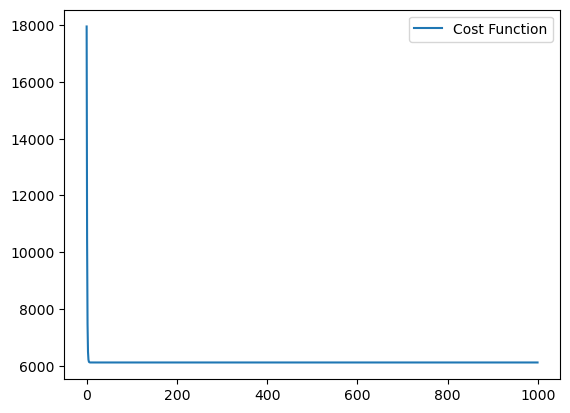

ValueError: operands could not be broadcast together with shapes (268,5) (6,) 

In [138]:
# print(model.cost_function_values)
plt.plot(model.cost_function_values,label="Cost Function")
plt.legend()
plt.show()
# print(model.test_model())
model.test_model()
plt.plot(model.metrics,label="Metrics")
plt.legend()
plt.show()


In [269]:
err = 0
for idx in range(300,1300):
    yi = model.hx(features[idx,:-1])
    y = features[idx,-1:]
    print(yi)
    print(y)
    err += abs(y-yi)
err/=1000
print("Error : ",err)


10050.35613312086
[7682.67]
9276.403034721296
[4889.9995]
13056.448862079613
[11944.59435]
8229.419645612608
[18972.495]
9740.994061161922
[7623.518]
13911.04751855447
[31620.00106]
10333.519771276315
[7050.0213]
12306.348940819391
[11879.10405]
12739.477881943889
[28101.33305]
11083.132863484336
[8988.15875]
7698.383749579698
[5354.07465]
9426.549575749377
[2927.0647]
9141.224463583192
[6455.86265]
6175.394539731577
[1635.73365]
9070.822373067398
[5272.1758]
10671.509185934045
[7265.7025]
12563.749214570373
[9800.8882]
10877.933243753541
[24873.3849]
7970.827119619307
[3292.52985]
6321.178791273496
[17352.6803]
5745.527211343437
[21595.38229]
8913.168652757982
[6710.1919]
11352.971693495587
[25517.11363]
10948.673254533962
[8703.456]
9126.952911617791
[20149.3229]
13361.170358689653
[36580.28216]
11892.09341811031
[9872.701]
7110.828761660816
[1141.4451]
11876.184586075535
[9283.562]
12279.874885596224
[14382.70905]
10404.225112873506
[8233.0975]
10168.266878017557
[5124.1887]
10816.9

In [31]:
print(model.metrics)

[-0.00742302]
